In [1]:
# common imports
import os
import time
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

# audio libraries
import librosa
import audiomentations
import IPython.display as ipd

# modeling imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import transforms
import torchvision.models as models

# documentation
import numpy.typing as npt
from typing import Optional, Union

In [ ]:
# where your data is
meta = pd.read_csv('../data/combined.small.csv')

# global variables for file paths
highest_folder = '/mnt/d/acoustics-data'
map_collection = {
    'iNat': 'birdclef-2026/train_audio',
    'XC': 'birdclef-2026/train_audio',
    'esc': 'ESC-50-master/ESC-50-master/audio',
    'arca23k': 'ARCA23K/ARCA23K.audio/ARCA23K.audio',
    'urban8k': 'UrbanSound8K/audio/foldall',
    'dbr': 'dbr-dataset/dataset/dograin',
    'freesound': 'freesound/outside',
    # 'random_noise': 'random-noise',
    # 'add': 'additional_data',
}
primary_labels = meta.primary_label.unique()
primary_to_common_name = (
    meta[['primary_label', 'common_name']]
    .drop_duplicates(subset='primary_label')
    .set_index('primary_label')['common_name']
    .to_dict()
)

meta = meta[~meta.collection.isin(['add','random-noise'])]
meta.reset_index(inplace=True, drop=True)

# global variables for mel spectrogram
height = 224 # n_mels
width = 224
fmin = 0
fmax = 16000
duration = 5

In [43]:

def reformat_image(input_tensor: torch.Tensor, 
                   image_size: tuple = (224,224), 
                   channel_size: int =3,
                   ) -> torch.Tensor:
    '''Prepare spectrogram for preexisting models
    
    Parameters
    ----------
    input_tensor : torch.Tensor
        Shape must be (B,C,H,W), (C,H,W), or (H,W)
    image_size : tuple
        Desired size (H*,W*)
    channel_size : int
        3 for RGB images

    Returns
    -------
    torch.Tensor
        Normalized and resized image(s)
    '''

    # insist on floating point precision
    input_tensor = input_tensor.detach().clone().to(dtype=torch.float32)

    # add batch dimension if single
    if len(input_tensor.shape) < 3:
        input_tensor = input_tensor.unsqueeze(0)
    if len(input_tensor.shape) < 4:
        input_tensor = input_tensor.unsqueeze(0)

    # convert to rgb in most cases
    if input_tensor.shape[1] != channel_size:
        input_tensor = input_tensor.repeat(1, channel_size, 1, 1)

    # normalize
    if input_tensor.max() > 1.0:
        input_tensor /= 255.0
    if channel_size == 3:
        normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    elif channel_size == 1:
        normalize = transforms.Normalize(mean=[0.449], std=[0.226])
    else:
        raise ValueError("Channel size is not 1 (grayscale) or 3 (RGB)")
    
    if input_tensor.shape[-2:] != image_size:
        preproc = transforms.Compose([
            transforms.Resize(image_size, interpolation=transforms.InterpolationMode.BICUBIC),
            normalize,
        ])
    else:
        preproc = transforms.Compose([
            normalize, 
        ])

    input_final = preproc(input_tensor)

    return input_final

def clean_row(row: pd.Series, ):
    '''Subset the useful info in each row'''
    row = row[
        [
            'primary_label',
            'common_name',
            'sampling_rate_hz',
            'start_seconds',
            'end_seconds',
            'filename',
            'collection',
            'latitude',
            'longitude',
            'class_name',
            'dataset'
        ]
    ]
    return dict(row)

def get_audio(row: dict, ):
    '''Load in the audio for a row'''
    fname = f'{highest_folder}/{map_collection[row['collection']]}/{row['filename']}'
    y, sr = librosa.load(fname, 
                         sr=row['sampling_rate_hz'],
                         duration=duration,
                         offset=row['start_seconds'],
                         )
    return y, sr

def get_mel(y: npt.NDArray, sr: int, ):
    '''Get a melspectrogram image'''
    l = sr * duration
    h = l / (width - 1)
    hupp = math.ceil(h) # calculate hop length
    x = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        hop_length=hupp,
        n_mels=height,
        fmin=fmin,
        fmax=fmax
    )
    if x.shape != (width, height):
        # force the array dim
        x = librosa.util.fix_length(x, size=width, axis=0)
        x = librosa.util.fix_length(x, size=height, axis=1)
    return x, hupp

In [80]:
class AudioDataset(Dataset):
    def __init__(self, df, le):
        """
        Parameters
        ----------
            df : pd.DataFrame
            le : sklearn.LabelEncoder
        """
        self.df = df.reset_index(drop=True) # Ensure indices are sequential
        self.le = le

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Get the row data
        row = self.df.iloc[idx]
        row = clean_row(row)

        # process the audio
        audio, sr = get_audio(row)
        x, h = get_mel(audio, sr)
        x = librosa.power_to_db(x, ref=np.max)
        
        # 4. Convert to tensor
        x_tensor = torch.from_numpy(x).float()
        x_tensor = x_tensor.unsqueeze(0)
        y = row['primary_label']
        y = self.le.transform([y])[0]
        y_tensor = torch.tensor(y)
        # y_tensor = F.one_hot(y_tensor, len(self.le.classes_)).float()
            
        return x_tensor, y_tensor

In [45]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes, channel_size):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(channel_size, 16, kernel_size=3, padding=1),   # 224x224
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 112x112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 56x56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 28x28

            nn.AdaptiveAvgPool2d((1, 1))                  # 1x1
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [ ]:
# prepare the datasets
train_data = meta[meta['dataset']=='train'].copy()
le = LabelEncoder()
le.fit(train_data['primary_label'])
val_data = meta[meta['dataset']=='validate'].copy()
test_data = meta[meta['dataset']=='test'].copy()
train_data.reset_index(inplace=True, drop=True)
val_data.reset_index(inplace=True, drop=True)
test_data.reset_index(inplace=True, drop=True)

White-tipped Dove


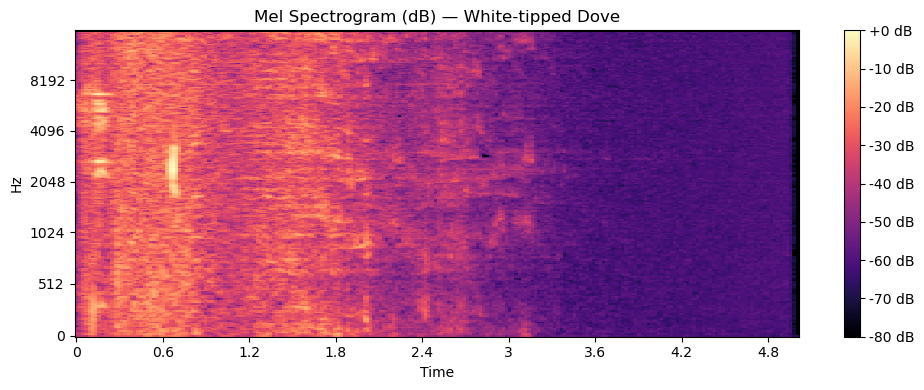

In [91]:
# listen to an example audio
idx = 15000
row = clean_row(train_data.iloc[idx])
y, sr = get_audio(row)
x, h = get_mel(y, sr)
print(row['common_name'])

# plot mel spectrogram in dB (power scale)
X_db = librosa.power_to_db(x.T, ref=np.max)  # transpose so rows = mel bins
plt.figure(figsize=(10, 4))
librosa.display.specshow(X_db, sr=int(sr), hop_length=int(h),
                         x_axis='time', 
                         y_axis='mel', 
                         fmin=fmin, 
                         fmax=fmax, 
                         cmap='magma',
                         )
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram (dB) — {row['common_name']}")
plt.tight_layout()
plt.show()

ipd.Audio(y, rate=sr)

In [49]:
# smaller subset: 8 batches of 32 samples = 256
n_samples = 16 * 16
batch_size = 16
num_classes = len(primary_labels)

# sample from test split (use .head(n_samples) instead of .sample(...) if you want deterministic order)
train_data_small = train_data.sample(n=min(n_samples, len(train_data)), random_state=42).reset_index(drop=True)
val_data_small = val_data.sample(n=min(n_samples, len(val_data)), random_state=42).reset_index(drop=True)

# optional: overwrite active dataset/dataloader to use the small subset
dataset_train = AudioDataset(train_data_small, le)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, num_workers=0, shuffle=False)
dataset_val = AudioDataset(val_data_small, le)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, num_workers=0, shuffle=False)
le = dataset_train.le

print("test_data_small:", len(train_data_small))
print("num batches:", len(dataloader_train))

test_data_small: 256
num batches: 16


In [ ]:
# weights = models.EfficientNet_B0_Weights.DEFAULT
# model = models.efficientnet_b0(weights=weights)

# in_features = model.classifier[1].in_features
# model.classifier = nn.Sequential(
#     nn.Dropout(p=0.2, inplace=True),
#     nn.Linear(in_features, num_classes),
# )

# criterion = nn.BCEWithLogitsLoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [50]:

# use this to see if code will run
model = SimpleCNN(num_classes=len(le.classes_), channel_size=1)
criterion = nn.CrossEntropyLoss()
# criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [51]:
# total and trainable parameter counts
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {total_params - trainable_params:,}")

Total parameters: 24,466
Trainable parameters: 24,466
Non-trainable parameters: 0


In [52]:
num_epochs = 2

image_size = (224, 224)
channel_size = 1

ft = open('training_loss.txt','w')
fv = open('validate_loss.txt','w')

for _ in range(num_epochs):

    # learning
    model.train()
    loss_total = 0
    itr = 0
    curr_time = time.time()
    for X, Y in dataloader_train:
        itr += 1
        optimizer.zero_grad()
        Z = reformat_image(X, 
                           image_size=image_size, 
                           channel_size=channel_size,
                           )
        logits = model(Z)
        loss = criterion(logits, Y)
        loss_total += loss
        loss.backward()
        optimizer.step()
    print(f'Epoch {_} took {time.time() - curr_time:4f} seconds')
    print('')

    # inference
    model.eval()
    with torch.no_grad():

        # training loss tracking
        loss_total = 0
        itr = 0
        for X, Y in dataloader_train:
            itr += 1
            Z = reformat_image(X, 
                           image_size=image_size, 
                           channel_size=channel_size,
                           )
            logits = model(Z)
            loss = criterion(logits, Y)
            loss_total += loss
        print(f'The training loss at epoch {_} is {loss_total / itr:6f}')
        ft.write(f"{loss_total / itr:6f}\n")

        # validation loss tracking
        loss_total = 0
        itr = 0
        for X, Y in dataloader_val:
            itr += 1
            Z = reformat_image(X, 
                           image_size=image_size, 
                           channel_size=channel_size,
                           )
            logits = model(Z)
            loss = criterion(logits, Y)
            loss_total += loss
        print(f'The validation loss at epoch {_} is {loss_total / itr:6f}')
        fv.write(f"{loss_total / itr:6f}\n")
    
    print('')

ft.close()
fv.close()

Epoch 0 took 36.774889 seconds

The training loss at epoch 0 is 2.216564
The validation loss at epoch 0 is 2.329614

Epoch 1 took 38.650649 seconds

The training loss at epoch 1 is 2.115248
The validation loss at epoch 1 is 2.158425



In [ ]:
# some initial summary statistics

from sklearn.metrics import f1_score

y_true_list = []
y_pred_list = []
val_loss_total = 0.0
n_batches = 0

model.eval()

with torch.no_grad():
    for X, Y_batch in dataloader_val:
        Z_batch = reformat_image(X, 
                                 image_size=image_size, 
                                 channel_size=channel_size,
                                 )
        logits = model(Z_batch)
        loss = criterion(logits, Y_batch)

        val_loss_total += loss.item()
        n_batches += 1

        y_true_list += list(Y_batch.cpu())
        y_pred_list += list(logits.argmax(axis=1).cpu())

y_true = y_true_list # odd to be tensors
y_pred = y_pred_list

print(f"Validation loss: {val_loss_total / n_batches:.6f}")
print(f"Subset accuracy: {accuracy_score(y_true, y_pred):.6f}")
print(f"Precision micro: {precision_score(y_true, y_pred, average='micro', zero_division=0):.6f}")
print(f"Precision macro: {precision_score(y_true, y_pred, average='macro', zero_division=0):.6f}")
print(f"Recall micro:    {recall_score(y_true, y_pred, average='micro', zero_division=0):.6f}")
print(f"Recall macro:    {recall_score(y_true, y_pred, average='macro', zero_division=0):.6f}")
print(f"F1 micro:        {f1_score(y_true, y_pred, average='micro', zero_division=0):.6f}")
print(f"F1 macro:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.6f}")

Validation loss: 2.158425
Subset accuracy: 0.144531
Precision micro: 0.144531
Precision macro: 0.058390
Recall micro:    0.144531
Recall macro:    0.093939
F1 micro:        0.144531
F1 macro:        0.028330


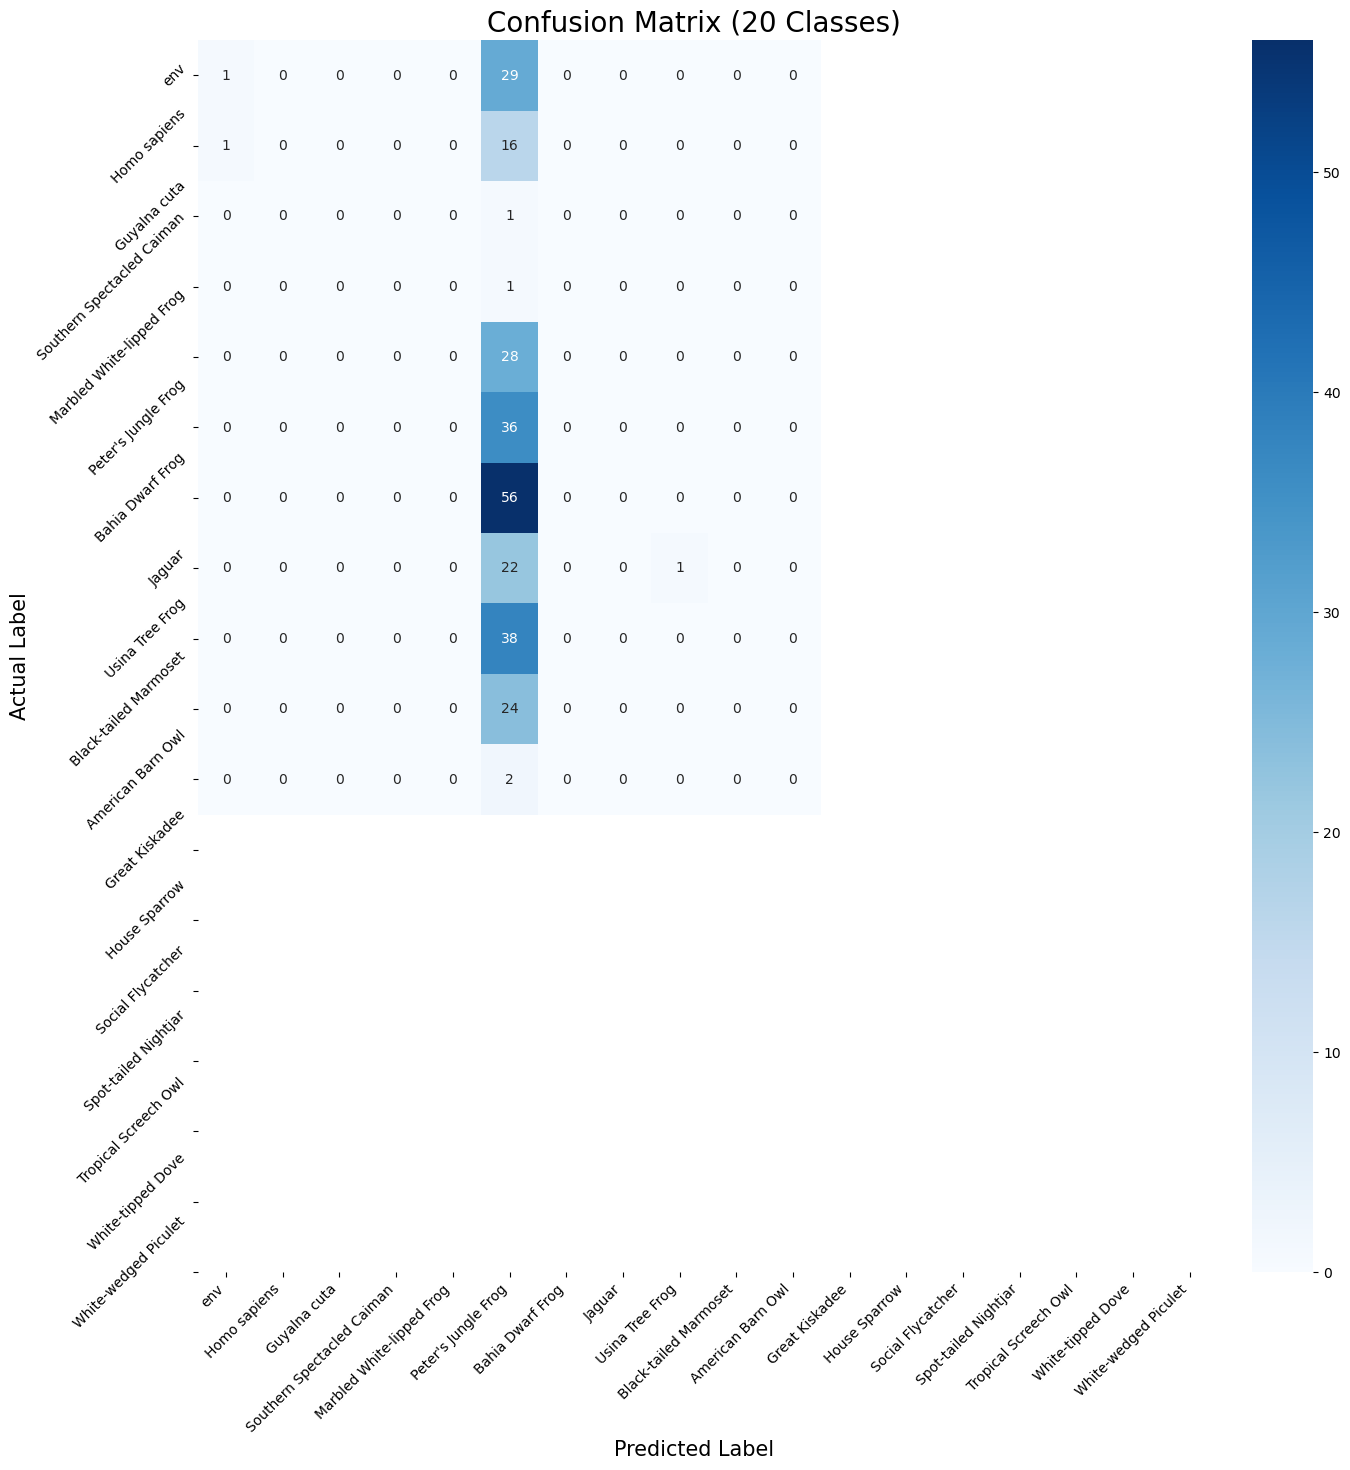

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Set a large figure size (at least 12-15 inches for 20 classes)
plt.figure(figsize=(16, 16))

# 3. Create the heatmap
# fmt='d' ensures integers are shown instead of scientific notation
class_names = le.classes_
class_names_long = [primary_to_common_name[cl] for cl in class_names]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_long, 
            yticklabels=class_names_long)

# 4. Clean up labels
plt.title('Confusion Matrix (20 Classes)', fontsize=20)
plt.ylabel('Actual Label', fontsize=15)
plt.xlabel('Predicted Label', fontsize=15)

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45, ha='right')
plt.show()
